Creating student dataset...
Dataset created: 500 students
Passed : 200 students
Failed : 300 students

Exploring data
   study_hrs  previous_score  attendance  sleep_hrs  passed
0         38              81          98          5       1
1         28              45          95          6       0
2         14              98          58          4       1
3          7              41          71          6       0
4         20              54          69          6       0
5         38              81          68          7       1
6         18              82          88          8       1
7         22              52          84          4       0
8         10              45          68          6       0
9         10              86          69          4       1

First 10 students

Basic Statistics
        study_hrs  previous_score  attendance   sleep_hrs      passed
count  500.000000      500.000000     500.000  500.000000  500.000000
mean    20.436000       63.936000      70.748

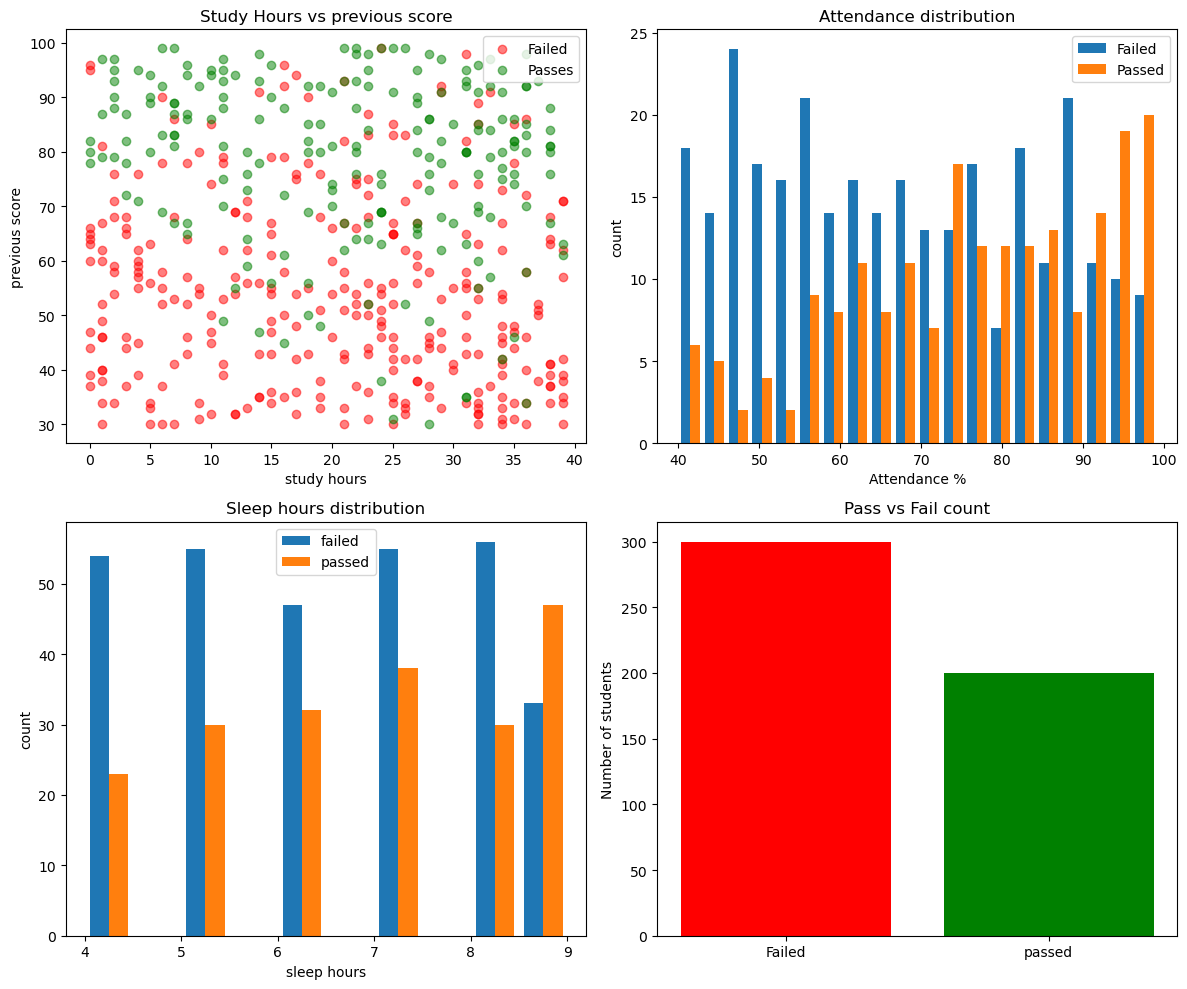

Preparing data
Features shape: (500, 4)
Target shape: (500,)

Training samples: 400
Testing samples: 100

Model 1: Logistic Regression
Logistic Regression Accuracy: 78.00%

Classification Report: 
              precision    recall  f1-score   support

      Failed       0.85      0.80      0.82        64
      Passed       0.68      0.75      0.71        36

    accuracy                           0.78       100
   macro avg       0.76      0.77      0.77       100
weighted avg       0.79      0.78      0.78       100

Model 2:Decision tree
Decision tree Accuracy: 82.00%

Classification Report: 
              precision    recall  f1-score   support

      Failed       0.87      0.84      0.86        64
      Passed       0.74      0.78      0.76        36

    accuracy                           0.82       100
   macro avg       0.80      0.81      0.81       100
weighted avg       0.82      0.82      0.82       100

Model Comparison

Logistic Regression: 78.00%

Decision Tree: 82.00%

W

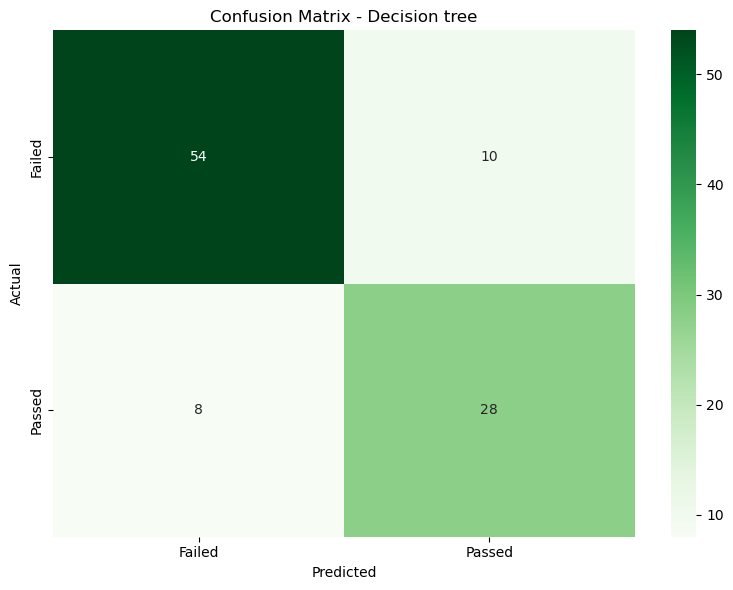

Testing on New students

New students to predict
   study_hrs  previous_score  attendance  sleep_hrs
0          5              45          50          5
1         25              85          90          7
2         15              65          75          6
3         35              90          95          8
4          2              40          45          4

Predictions
Student1: Fail
  Study: 5h, Previous: 45%, Attendance: 50%, Sleep: 5h
Student2: Pass
  Study: 25h, Previous: 85%, Attendance: 90%, Sleep: 7h
Student3: Fail
  Study: 15h, Previous: 65%, Attendance: 75%, Sleep: 6h
Student4: Pass
  Study: 35h, Previous: 90%, Attendance: 95%, Sleep: 8h
Student5: Fail
  Study: 2h, Previous: 40%, Attendance: 45%, Sleep: 4h
Student Predictor complete


In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.tree import DecisionTreeClassifier
import seaborn as sns

print("Creating student dataset...")
np.random.seed(42)
n_students = 500

study_hrs = np.random.randint(0,40,n_students)
previous_score = np.random.randint(30,100,n_students)
attendance = np.random.randint(40,100,n_students)
sleep_hrs = np.random.randint(4,10,n_students)

pass_score = (
    study_hrs*0.4+
    previous_score*0.5+
    attendance*0.3+
    sleep_hrs*2
)

pass_score= pass_score + np.random.normal(0,10,n_students)

threshold = np.percentile(pass_score,60)
passed = (pass_score>threshold).astype(int)

df = pd.DataFrame({
    'study_hrs' : study_hrs,
    'previous_score' : previous_score,
    'attendance': attendance,
    'sleep_hrs': sleep_hrs,
    'passed': passed
})

print(f"Dataset created: {len(df)} students")
print(f"Passed : {sum(df['passed']==1)} students")
print(f"Failed : {sum(df['passed'] ==0)} students")
print()

print('='*50)
print("Exploring data")
print('='*50)

print(df.head(10))
print('\nFirst 10 students')
print()

print("Basic Statistics")
print(df.describe())

print("\nAverage stats for passed students: ")
print(df[df['passed']==1].mean())

print("\nAverage stats for failed students: ")
print(df[df['passed']==0].mean())

print()

print('='*50)
print("Visualizing data")
print('='*50)

fig , axes = plt.subplots(2,2,figsize=(12,10))
axes[0,0].scatter(df[df['passed']==0]['study_hrs'],
                 df[df['passed']==0]['previous_score'],
                 c = 'red' , label = 'Failed' , alpha = 0.5)

axes[0,0].scatter(df[df['passed']==1]['study_hrs'],
                 df[df['passed']==1]['previous_score'],
                 c = 'green' , label = 'Passes' , alpha = 0.5)

axes[0,0].set_xlabel('study hours')
axes[0,0].set_ylabel('previous score')
axes[0,0].set_title('Study Hours vs previous score')
axes[0,0].legend()


axes[1,0].hist([df[df['passed'] == 0]['sleep_hrs'],
              df[df['passed']==1]['sleep_hrs']],
              label = ['failed','passed'], bins = 10)
axes[1,0].set_xlabel('sleep hours')
axes[1,0].set_ylabel('count')
axes[1,0].set_title('Sleep hours distribution')
axes[1,0].legend()

axes[0,1].hist([df[df['passed']==0]['attendance'],
               df[df['passed']==1]['attendance']]
               ,label = ['Failed','Passed'],bins = 20)
axes[0,1].set_xlabel('Attendance %')
axes[0,1].set_ylabel('count')
axes[0,1].set_title('Attendance distribution')
axes[0,1].legend()

pass_rate = [sum(df['passed']==0) , sum(df['passed']==1)]
axes[1,1].bar(['Failed' , 'passed'] , pass_rate , color = ['red' , 'green'])
axes[1,1].set_ylabel('Number of students')
axes[1,1].set_title('Pass vs Fail count')

plt.tight_layout()
plt.savefig('Student_eda.png' , dpi = 300, bbox_inches = 'tight')
print("Visualization saved as student_eda.png")
plt.show()


print('='*50)
print("Preparing data")
print('='*50)

x = df.drop('passed' , axis=1)
y = df['passed']

print(f"Features shape: {x.shape}")
print(f"Target shape: {y.shape}")
print()

x_train , x_test , y_train , y_test = train_test_split(x , y , test_size = 0.2 , random_state = 42)

print(f"Training samples: {len(x_train)}")
print(f"Testing samples: {len(x_test)}")
print()

print('='*50)
print('Model 1: Logistic Regression')
print('='*50)

model_lr = LogisticRegression()  
model_lr.fit(x_train , y_train)
y_pred_lr = model_lr.predict(x_test)

accuracy_lr = accuracy_score(y_test , y_pred_lr)
print(f"Logistic Regression Accuracy: {accuracy_lr*100:.2f}%")
print('\nClassification Report: ')
print(classification_report(y_test , y_pred_lr , target_names = ['Failed' , 'Passed']))


print('='*50)
print("Model 2:Decision tree")
print('='*50)

model_dt = DecisionTreeClassifier(max_depth = 5)
model_dt.fit(x_train,y_train)
y_pred_dt = model_dt.predict(x_test)

accuracy_dt = accuracy_score(y_test , y_pred_dt)
print(f"Decision tree Accuracy: {accuracy_dt*100:.2f}%")
print('\nClassification Report: ')
print(classification_report(y_test , y_pred_dt , target_names = ['Failed' , 'Passed']))


print('='*50)
print("Model Comparison")
print('='*50)

print(f"\nLogistic Regression: {accuracy_lr*100:.2f}%")
print(f"\nDecision Tree: {accuracy_dt*100:.2f}%")

if accuracy_lr > accuracy_dt:
    print("\nWinner: Logistic Regression!")
elif accuracy_lr < accuracy_dt:
    print("\nWinner: Decision Tree!")
else:
    print("\nIts a tie")


print()
print('='*50)
print("CONFUSION MATRIX - BEST MODEL")
print('='*50)

best_pred = y_pred_dt if accuracy_dt >= accuracy_lr else y_pred_lr
best_name = "Decision tree" if accuracy_dt >= accuracy_lr else "Logistic Regression"

cm = confusion_matrix(y_test , best_pred)
print(f"\nConfusion Matrix ({best_name})")
print(cm)

plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True , fmt ='d',cmap='Greens',
            xticklabels=['Failed', 'Passed'],
            yticklabels=['Failed', 'Passed'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix - {best_name}')
plt.tight_layout()
plt.savefig('student_confusion_matrix.png', dpi=300, bbox_inches='tight')
print("\nConfusion Matrix Saved")
plt.show()

print('='*50)
print("Testing on New students")
print('='*50)

new_students = pd.DataFrame({
     'study_hrs': [5, 25, 15, 35, 2],
     'previous_score': [45, 85, 65, 90, 40],
     'attendance': [50, 90, 75, 95, 45],
     'sleep_hrs': [5, 7, 6, 8, 4]
})
print("\nNew students to predict")
print(new_students)

best_model = model_dt if accuracy_dt >= accuracy_lr else model_lr
new_predictions = best_model.predict(new_students)

print("\nPredictions")
for i, pred in enumerate(new_predictions):
    result = "Pass" if pred == 1 else "Fail"
    print(f"Student{i+1}: {result}")
    print(f"  Study: {new_students.iloc[i]['study_hrs']}h, "
          f"Previous: {new_students.iloc[i]['previous_score']}%, "
          f"Attendance: {new_students.iloc[i]['attendance']}%, "
          f"Sleep: {new_students.iloc[i]['sleep_hrs']}h")

print('='*50)
print("Student Predictor complete")
print('='*50)